# 08 — Precision: BF16 vs INT8

**Objective.** Separate the effect of the weight representation from the effect of the engine, and prepare the
controlled INT8 backend comparison (vLLM W8A8 vs llama.cpp Q8_0).

**Research questions.**
1. What does INT8 change inside llama.cpp (Q8_0 vs BF16), and does it change the shape of its scaling curve?
2. Does the backend ranking at matched BF16 precision survive when llama.cpp uses its best configuration (INT8)?
3. What is the status of the INT8 backend pair, and how will it enter the analysis?

**Data.** `online_points` (campaign `online/main`) and `quality_check` (16 prompts × 64 greedy tokens per
configuration, 8B, on a non-HBM `cresco8_cpu` node).

**Method and fairness.** Precision effects are formed *within* a backend (`comparisons.precision_ratio`).
Comparisons across backends *and* precisions are labelled as not precision-controlled. The INT8 backend pair is
discovered from metadata (`comparisons.backend_pairs`): when vLLM INT8 results are added, every cell of this
notebook includes them without code changes.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "08_precision_int8.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
pts = metrics.add_scaling_metrics(loaders.online_points())
conf = registry.configurations_frame()
measured = set(pts["configuration_id"])
display(table(conf.assign(in_data=conf["configuration_id"].isin(measured).map({True: "yes", False: "no"}))
              [["label", "precision", "quantization", "weight_format", "status", "in_data"]]
              .rename(columns={"label": "Configuration", "precision": "Precision", "quantization": "Quantization",
                               "weight_format": "Weights", "status": "Status (metadata)", "in_data": "Online data present"})))
models = registry.experiment_config()["models"]
bytes_tbl = pd.DataFrame([{"Model": registry.model_label(m), **{f"{k.upper()} (GB/step)": v / 1e9
                           for k, v in models[m]["step_weight_bytes"].items()}} for m in models])
display(table(bytes_tbl, {c: "{:.2f}" for c in bytes_tbl.columns[1:]},
              caption="Weight bytes streamed per forward step, from the checkpoint headers"))

Configuration,Precision,Quantization,Weights,Status (metadata),Online data present
vLLM · BF16,bf16,none,safetensors (HF snapshot),measured,yes
llama.cpp · BF16,bf16,none,GGUF BF16 (lossless conversion of the same snapshot),measured,yes
llama.cpp · INT8 (Q8_0),int8,q8_0,"GGUF Q8_0 (RTN, one scale per 32 weights, from the BF16 GGUF)",measured,yes
vLLM · INT8 (W8A8),int8,w8a8_rtn,"compressed-tensors W8A8 (RTN, per-channel weights, dynamic per-token activations)",pending,no


Model,BF16 (GB/step),Q8_0 (GB/step),W8A8 (GB/step)
Llama-3.1-8B,15.01,7.97,8.03
Llama-3.2-1B,2.47,1.31,1.50


W8A8 and Q8_0 stream almost the same number of bytes per step (about half of BF16), so the INT8 pair is matched
in memory traffic per step. Remaining differences: scale granularity, and the lm_head (BF16 in vLLM's
checkpoint, int8 in Q8_0).

## 1. INT8 vs BF16 inside llama.cpp

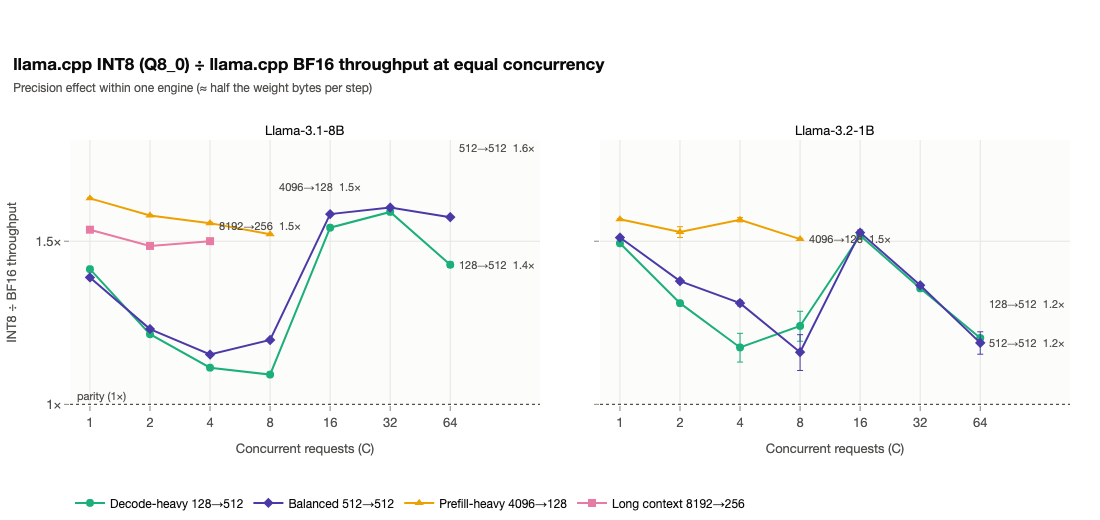

Model,Workload,"Peak ÷ C=1, BF16","Peak ÷ C=1, INT8","Peak at C, BF16","Peak at C, INT8"
Llama-3.1-8B,128→512,5.8×,6.6×,32,32
Llama-3.1-8B,512→512,3.8×,4.5×,32,32
Llama-3.1-8B,4096→128,1.2×,1.1×,4,4
Llama-3.1-8B,8192→256,1.1×,1.0×,4,4
Llama-3.1-8B,4096→1024,1.7×,–,16,–
Llama-3.2-1B,128→512,3.6×,3.6×,32,16
Llama-3.2-1B,512→512,3.2×,3.0×,32,16
Llama-3.2-1B,4096→128,1.2×,1.2×,2,4


llama.cpp INT8 ÷ BF16 throughput: 1.08×–1.67× across all points.

In [3]:
pr = comparisons.precision_ratio(pts, "llama_cpp", "total_tok_s_mean")
fig = plots.ratio_vs_concurrency(pr, title="llama.cpp INT8 (Q8_0) ÷ llama.cpp BF16 throughput at equal concurrency",
                                 subtitle="Precision effect within one engine (≈ half the weight bytes per step)",
                                 y_title="INT8 ÷ BF16 throughput")
fig.show()
export_figure(fig, "llama_cpp_int8_over_bf16", source=NOTEBOOK,
              caption="llama.cpp Q8_0 ÷ BF16 throughput vs concurrency per workload: INT8 raises the level, not the scaling.")
s = metrics.curve_summary(pts)
l = s[s["backend"] == "llama_cpp"].sort_values(["model", "workload_order"]).pivot_table(
    index=["model_label", "workload_shape"], columns="precision", values=["peak_over_c1", "peak_concurrency"], sort=False)
l.columns = [f"{a} {b}" for a, b in l.columns]
display(table(l.reset_index().rename(columns={"model_label": "Model", "workload_shape": "Workload",
                                              "peak_over_c1 bf16": "Peak ÷ C=1, BF16", "peak_over_c1 int8": "Peak ÷ C=1, INT8",
                                              "peak_concurrency bf16": "Peak at C, BF16", "peak_concurrency int8": "Peak at C, INT8"}),
              {"Peak ÷ C=1, BF16": "{:.1f}×", "Peak ÷ C=1, INT8": "{:.1f}×", "Peak at C, BF16": "{:.0f}", "Peak at C, INT8": "{:.0f}"}))
show(f"llama.cpp INT8 ÷ BF16 throughput: {rng(pr['ratio'], x, nd=2)} across all points.")

**Interpretation.** INT8 makes llama.cpp faster at every concurrency (fewer bytes per token, AMX-INT8 for batched
weight GEMMs), but its scaling factor and the concurrency at which it peaks stay close to BF16's: quantization moves
llama.cpp's curve up, it does not let llama.cpp use more concurrency.

## 2. Does the backend ranking survive llama.cpp's best configuration?

*Not precision-controlled:* vLLM BF16 streams about twice the bytes per step of llama.cpp INT8. The comparison
answers a practical question (is vLLM BF16 still the stronger serving platform than llama.cpp at its fastest?),
not an engine question.

In [4]:
vi = s[(s["configuration_id"] == "vllm_bf16")].set_index(["model", "workload"])
li = s[(s["configuration_id"] == "llama_cpp_int8")].set_index(["model", "workload"])
both = vi.index.intersection(li.index)
peak = (vi.loc[both, "peak_total_tok_s"] / li.loc[both, "peak_total_tok_s"])
c1 = (vi.loc[both, "c1_total_tok_s"] / li.loc[both, "c1_total_tok_s"])
show(f"vLLM BF16 ÷ llama.cpp INT8 (cross-precision): at C = 1 {rng(c1, x, nd=2)}; peak vs peak {rng(peak, x)}.")

vLLM BF16 ÷ llama.cpp INT8 (cross-precision): at C = 1 0.51×–1.95×; peak vs peak 3.3×–6.1×.

**Interpretation.** At one request llama.cpp INT8 is faster than vLLM BF16 on the short-prompt shapes, as expected
from half the bytes per token. At each backend's best operating point, vLLM BF16 still delivers several times the
throughput of llama.cpp's fastest configuration. The backend decision therefore does not hinge on the precision
mismatch.

## 3. INT8 backend pair (vLLM W8A8 vs llama.cpp Q8_0)

In [5]:
pairs = comparisons.backend_pairs(pts)
display(table(pairs.assign(model=pairs["model"].map(registry.model_label)).rename(columns={"model": "Model", "precision": "Precision"}),
              caption="Precision classes with measurements for both backends"))
if (pairs["precision"] == "int8").any():
    r8 = comparisons.backend_ratio(pts, "total_tok_s_mean", precision="int8")
    fig = plots.ratio_vs_concurrency(r8, title="vLLM ÷ llama.cpp aggregate throughput at equal concurrency (INT8 pair)",
                                     subtitle="vLLM W8A8 vs llama.cpp Q8_0 · > 1 means vLLM delivers more tokens/s",
                                     y_title="vLLM ÷ llama.cpp throughput")
    fig.show()
    export_figure(fig, "backend_ratio_vs_concurrency_int8", source=NOTEBOOK,
                  caption="vLLM W8A8 ÷ llama.cpp Q8_0 throughput at equal C per workload.")
    display(table(comparisons.crossover_summary(r8)))
else:
    show("**Pending.** No vLLM INT8 (W8A8) online measurements are in `data/raw/` yet, so the INT8 backend pair cannot be "
         "formed. When the `int8-campaign` results are synced and `make data` is re-run, this cell plots and tabulates "
         "the pair automatically, and notebooks 04–07 and 09 include the new configuration.")

Model,Precision
Llama-3.1-8B,bf16
Llama-3.2-1B,bf16


**Pending.** No vLLM INT8 (W8A8) online measurements are in `data/raw/` yet, so the INT8 backend pair cannot be formed. When the `int8-campaign` results are synced and `make data` is re-run, this cell plots and tabulates the pair automatically, and notebooks 04–07 and 09 include the new configuration.

## 4. Quality sanity check of the INT8 checkpoints

Before the INT8 campaign, all four configurations were run on 16 natural-text prompts (64 greedy tokens each) to
verify that the self-built W8A8 checkpoint loads in vLLM's image and that the INT8 paths execute AMX. Agreement is
measured against a BF16 reference as identical continuations and common word prefix.

In [6]:
q = loaders.quality_check()
qq = (q[q["comparison"] != "reference"]
      .assign(reference=lambda d: d["reference_configuration_id"].map(registry.configuration_label))
      .drop_duplicates(["configuration_id", "reference_configuration_id"]))
display(table(qq[["configuration_label", "comparison", "reference", "identical_continuations", "mean_common_prefix_words",
                  "min_common_prefix_words", "amx_busy_frac"]]
              .rename(columns={"configuration_label": "Configuration", "comparison": "Comparison", "reference": "Reference",
                               "identical_continuations": f"Identical (of {int(q['prompts'].iloc[0])})",
                               "mean_common_prefix_words": "Mean common prefix (words)",
                               "min_common_prefix_words": "Min common prefix", "amx_busy_frac": "AMX busy fraction"}),
              {"Mean common prefix (words)": "{:.1f}", "AMX busy fraction": "{:.4f}",
               f"Identical (of {int(q['prompts'].iloc[0])})": "{:.0f}", "Min common prefix": "{:.0f}"},
              caption=f"Run on {q['host'].iloc[0]} ({q['cpu_model'].iloc[0]})"))

Configuration,Comparison,Reference,Identical (of 16),Mean common prefix (words),Min common prefix,AMX busy fraction
llama.cpp · BF16,same_engine_bf16,vLLM · BF16,13,40.8,1,0.0000
llama.cpp · INT8 (Q8_0),same_engine_bf16,llama.cpp · BF16,11,37.5,1,0.0006
llama.cpp · INT8 (Q8_0),vllm_bf16,vLLM · BF16,12,41.3,13,0.0006
vLLM · INT8 (W8A8),same_engine_bf16,vLLM · BF16,5,21.9,0,0.0004


**Interpretation.** All configurations produce fluent output; the int8 configurations register AMX activity.
vLLM's data-free W8A8 drifts from its BF16 reference earlier than llama.cpp's Q8_0 does — a fidelity difference
that does not favour vLLM, consistent with coarser per-channel/per-token scales without calibration (SmoothQuant
or GPTQ would narrow it but would no longer be a like-for-like RTN counterpart of Q8_0). Throughput depends on
bytes and arithmetic, which are matched, not on which tokens are generated (fixed output length).

## Conclusions

- **Measured:** INT8 raises llama.cpp's throughput at every C but leaves its scaling shape unchanged; vLLM BF16
  remains several times faster than llama.cpp INT8 at each backend's best operating point.
- **Pending:** the controlled INT8 backend comparison (vLLM W8A8 vs llama.cpp Q8_0) — checkpoints built and
  quality-checked, tuning and campaign not yet run.
- **Implication:** the backend decision rests on the BF16 pair and is not reversed by llama.cpp's quantized
  configuration; the INT8 pair will test whether the conclusion also holds when both engines use AMX-INT8.

## Limitations

- The quality check ran on a Xeon Platinum 8592+ node, not on the Xeon Max nodes, and covers 16 prompts.
- llama.cpp INT8 at 4096→1024 (8B) and the 1B INT8 offline job are missing (nodes drained for maintenance).